# Farthest Point Sampling on MACE Latent Embeddings
This notebook performs FPS on structure-level latent embeddings from a MACE model.

## 1. Setup and Imports

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist, pdist, squareform
import os

# Set seed for reproducible results if needed for tie breaking (though FPS should be deterministic)
np.random.seed(42)


## 2. Configuration

In [3]:
INPUT_FILE = "/home/mehuldarak/athena/structure_level_latents/structure_level_latents_all.json"
OUTPUT_TABLE = "/home/mehuldarak/athena/structure_level_latents/fps_selection_maceomat.csv"

K = 20  # Number of structures to select
USE_PCA = True
INIT_METHOD = "lowest-energy"  # "closest-to-centroid" or "lowest-energy"


## 3. Data Loading and Preprocessing
- Load JSON
- Filter structures with `mace_energy` > 0
- L2-normalize embeddings

In [4]:
# Load data
with open(INPUT_FILE, "r") as f:
    data = json.load(f)

print(f"Total structures loaded: {len(data)}")

# Filter out positive energy structures
data_filtered = [d for d in data if d["mace_energy"] <= 0]
print(f"Structures after removing positive energy: {len(data_filtered)}")

# Extract arrays
filenames = np.array([d["file"] for d in data_filtered])
energies = np.array([d["mace_energy"] for d in data_filtered])

# Load embeddings
embeddings = np.array([d["structure_embedding"] for d in data_filtered])
print(f"Original embeddings shape: {embeddings.shape}")

# L2 Normalize embeddings
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1 # Prevent division by zero
embeddings_norm = embeddings / norms
print("Embeddings L2-normalized.")


Total structures loaded: 5297
Structures after removing positive energy: 5297
Original embeddings shape: (5297, 256)
Embeddings L2-normalized.


## 4. Optional PCA Dimensionality Reduction
- Fit PCA to keep $\ge 95\%$ variance
- Enforce strictly $\ge 32$ dimensions
- Distance preservation check
- 3D Plots from 5 angles

Components for 95% variance: 1
Selected dimensions for FPS (min 32): 32
Mean fractional distance change after PCA: 0.0002


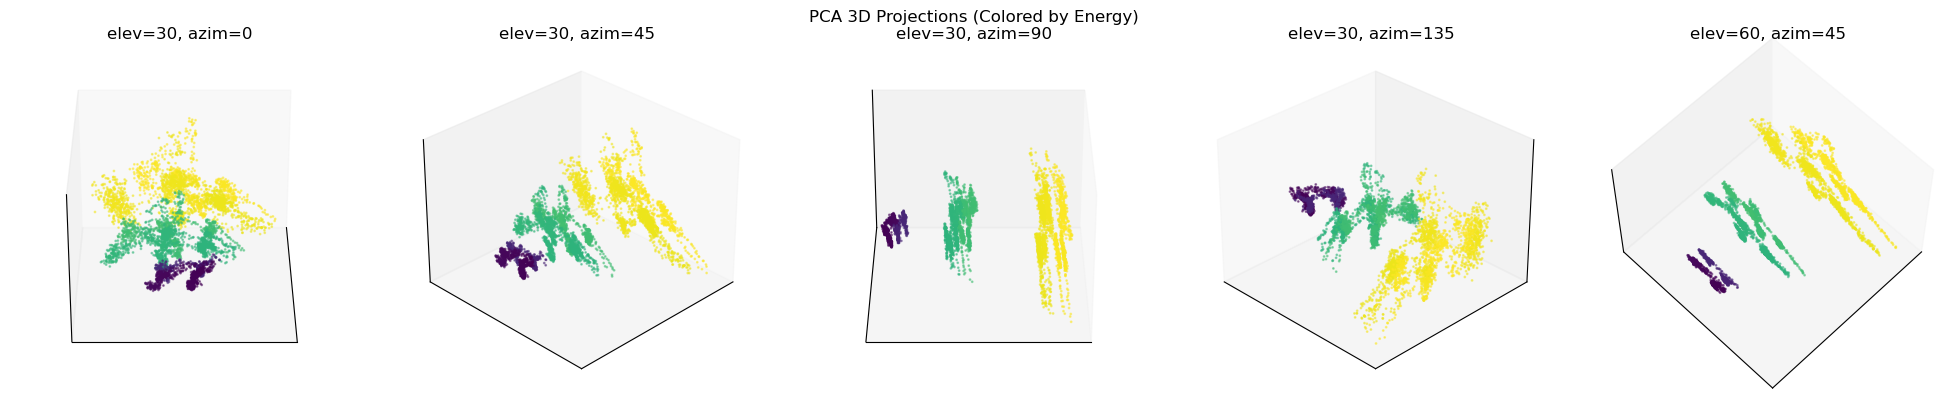

In [5]:
if USE_PCA:
    # First, run PCA without limits to find variance ratios
    pca_full = PCA()
    pca_full.fit(embeddings_norm)
    cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Find number of components for 95% variance
    n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
    n_components = max(32, n_components_95)
    
    print(f"Components for 95% variance: {n_components_95}")
    print(f"Selected dimensions for FPS (min 32): {n_components}")
    
    # Transform using selected components
    pca = PCA(n_components=n_components)
    fps_embeddings = pca.fit_transform(embeddings_norm)
    
    # Distance Preservation Check (on a subset of max 2000 points to save memory)
    n_check = min(2000, len(embeddings_norm))
    idx_check = np.random.choice(len(embeddings_norm), n_check, replace=False)
    
    orig_dists = pdist(embeddings_norm[idx_check])
    pca_dists = pdist(fps_embeddings[idx_check])
    
    preservation_error = np.mean(np.abs(orig_dists - pca_dists) / (orig_dists + 1e-8))
    print(f"Mean fractional distance change after PCA: {preservation_error:.4f}")
    
    # Plotting 3D PCA
    if n_components >= 3:
        fig = plt.figure(figsize=(20, 4))
        angles = [(30, 0), (30, 45), (30, 90), (30, 135), (60, 45)]
        
        for i, (elev, azim) in enumerate(angles):
            ax = fig.add_subplot(1, 5, i+1, projection='3d')
            # Plot a subset for clarity if dataset is large, or use small alpha
            ax.scatter(fps_embeddings[:, 0], fps_embeddings[:, 1], fps_embeddings[:, 2], 
                       s=1, alpha=0.5, c=energies, cmap='viridis')
            ax.view_init(elev=elev, azim=azim)
            ax.set_title(f"elev={elev}, azim={azim}")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
        
        plt.suptitle("PCA 3D Projections (Colored by Energy)")
        plt.tight_layout()
        plt.show()
else:
    fps_embeddings = embeddings_norm
    print("PCA skipped. Using raw normalized embeddings.")


## 5. Farthest Point Sampling (FPS)
- Deterministic initialization
- Greedy FPS using Euclidean distance on the embedding space

In [6]:
N = len(fps_embeddings)

if K > N:
    raise ValueError(f"K={K} cannot exceed number of points N={N}")

selected_indices = []
min_dists = np.full(N, np.inf)

# --------------------------------------------------
# 1. Initialization
# --------------------------------------------------
if INIT_METHOD == "lowest-energy":
    first_idx = np.argmin(energies)
elif INIT_METHOD == "closest-to-centroid":
    centroid = np.mean(fps_embeddings, axis=0, keepdims=True)
    dists_to_centroid = cdist(
        fps_embeddings, centroid, metric="euclidean"
    ).flatten()
    first_idx = np.argmin(dists_to_centroid)
else:
    raise ValueError(f"Unknown INIT_METHOD: {INIT_METHOD}")

selected_indices.append(first_idx)
fps_selection_dists = [0.0]

print(
    f"Selected first point {first_idx} using {INIT_METHOD}. "
    f"Energy: {energies[first_idx]:.4f}"
)

# Distance update
current_pt = fps_embeddings[first_idx:first_idx + 1]
new_dists = cdist(fps_embeddings, current_pt, metric="euclidean").flatten()
min_dists = np.minimum(min_dists, new_dists)

# IMPORTANT: forbid reselection
min_dists[first_idx] = -np.inf

# --------------------------------------------------
# 2. Greedy FPS loop
# --------------------------------------------------
for i in range(1, K):
    # Pick point farthest from current selected set
    next_idx = np.argmax(min_dists)
    max_dist = min_dists[next_idx]

    selected_indices.append(next_idx)
    fps_selection_dists.append(max_dist)

    # Update distances
    current_pt = fps_embeddings[next_idx:next_idx + 1]
    new_dists = cdist(fps_embeddings, current_pt, metric="euclidean").flatten()
    min_dists = np.minimum(min_dists, new_dists)

    # IMPORTANT: forbid reselection
    min_dists[next_idx] = -np.inf

    if (i + 1) % max(1, K // 10) == 0:
        print(f"Selected {i + 1}/{K} structures...")

selected_indices = np.array(selected_indices)

print("FPS completed.")

Selected first point 2717 using lowest-energy. Energy: -8624.1582
Selected 2/20 structures...
Selected 4/20 structures...
Selected 6/20 structures...
Selected 8/20 structures...
Selected 10/20 structures...
Selected 12/20 structures...
Selected 14/20 structures...
Selected 16/20 structures...
Selected 18/20 structures...
Selected 20/20 structures...
FPS completed.


## 6. Coverage Statistics and Diagnostics
- Distances to nearest selected point (over full dataset and selected set)
- Coverage curve
- FPS selection distance vs selection index

=== FPS Coverage Statistics ===
Full Dataset nearest coverage:
  Min dist:  0.0000
  Mean dist: 0.0093
  Max dist:  0.0176

Selected Set pairwise separation:
  Min dist:  0.0180
  Mean dist: 0.0207
  Max dist:  0.0285


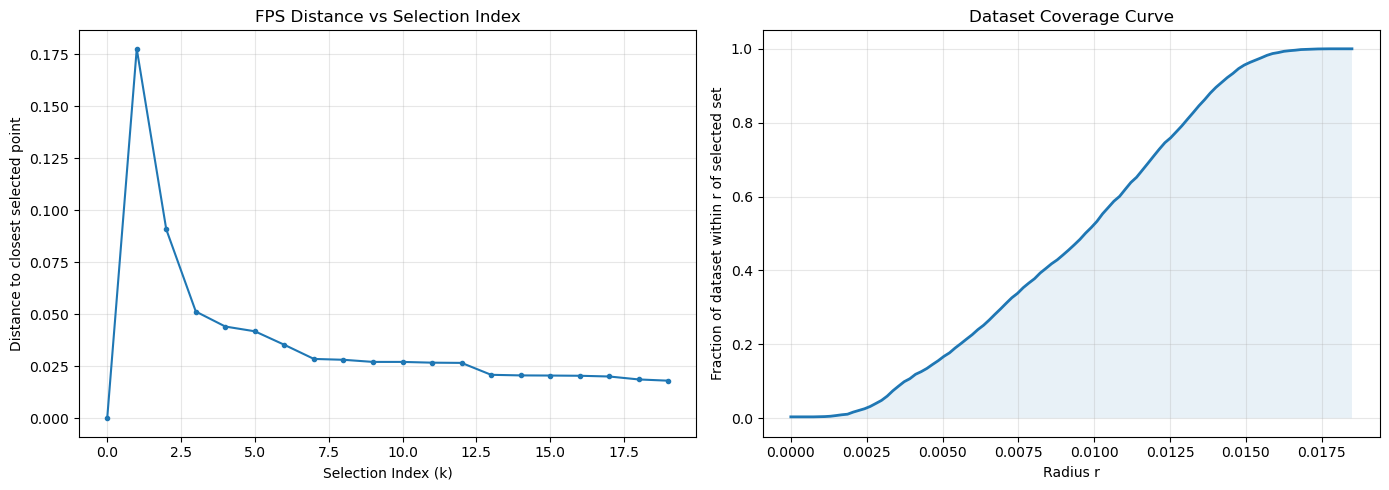

In [7]:
# --------------------------------------------------
# Coverage statistics (RECOMPUTE CLEANLY)
# --------------------------------------------------

# Embeddings of selected structures
selected_fps_embs = fps_embeddings[selected_indices]

# Distance from every point to its nearest selected point
full_dataset_min_dists = np.min(
    cdist(fps_embeddings, selected_fps_embs, metric="euclidean"),
    axis=1
)

print("=== FPS Coverage Statistics ===")
print("Full Dataset nearest coverage:")
print(f"  Min dist:  {np.min(full_dataset_min_dists):.4f}")
print(f"  Mean dist: {np.mean(full_dataset_min_dists):.4f}")
print(f"  Max dist:  {np.max(full_dataset_min_dists):.4f}")

# --------------------------------------------------
# Selected-set internal separation
# --------------------------------------------------

# Pairwise distances among selected points
pairwise_selected = squareform(
    pdist(selected_fps_embs, metric="euclidean")
)

# Ignore self-distances
np.fill_diagonal(pairwise_selected, np.inf)

selected_set_min_dists = np.min(pairwise_selected, axis=1)

print("\nSelected Set pairwise separation:")
print(f"  Min dist:  {np.min(selected_set_min_dists):.4f}")
print(f"  Mean dist: {np.mean(selected_set_min_dists):.4f}")
print(f"  Max dist:  {np.max(selected_set_min_dists):.4f}")

# --------------------------------------------------
# Plots
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: FPS selection distance vs index
axes[0].plot(
    range(K),
    fps_selection_dists,
    marker=".",
    linestyle="-"
)
axes[0].set_title("FPS Distance vs Selection Index")
axes[0].set_xlabel("Selection Index (k)")
axes[0].set_ylabel("Distance to closest selected point")
axes[0].grid(True, alpha=0.3)

# Plot 2: Coverage curve
r_vals = np.linspace(
    0,
    np.max(full_dataset_min_dists) * 1.05,
    100
)
coverage_frac = [
    np.mean(full_dataset_min_dists <= r)
    for r in r_vals
]

axes[1].plot(r_vals, coverage_frac, linewidth=2)
axes[1].fill_between(r_vals, coverage_frac, alpha=0.1)
axes[1].set_title("Dataset Coverage Curve")
axes[1].set_xlabel("Radius r")
axes[1].set_ylabel("Fraction of dataset within r of selected set")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
coverage_percentiles = np.percentile(
    full_dataset_min_dists,
    [1, 5, 10, 25, 50, 75, 90, 95, 99]
)

print("\nDataset coverage distance percentiles:")
for p, v in zip([1,5,10,25,50,75,90,95,99], coverage_percentiles):
    print(f"  {p:>2}th percentile: {v:.4f}")


Dataset coverage distance percentiles:
   1th percentile: 0.0018
   5th percentile: 0.0030
  10th percentile: 0.0038
  25th percentile: 0.0063
  50th percentile: 0.0097
  75th percentile: 0.0124
  90th percentile: 0.0141
  95th percentile: 0.0148
  99th percentile: 0.0161


## 7. Outputs

In [9]:
# --------------------------------------------------
# Create table of selected points
# --------------------------------------------------

results = []
for rank, idx in enumerate(selected_indices):
    results.append({
        "FPS_Rank": rank + 1,
        "Filename": filenames[idx],
        "MACE_Energy": energies[idx],
        "Min_Distance_At_Selection": fps_selection_dists[rank]
    })

df_results = pd.DataFrame(results)

# Sort explicitly by FPS rank (safety)
df_results = df_results.sort_values("FPS_Rank").reset_index(drop=True)

# Display preview
display(df_results.head(10))

# Save output (prefer Excel or JSON if desired)
df_results.to_csv(OUTPUT_TABLE, index=False)
print(f"\nSaved top {K} selections to {OUTPUT_TABLE}")

,FPS_Rank,Filename,MACE_Energy,Min_Distance_At_Selection
0,1,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-8624.158203,0.000000
1,2,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-2164.930664,0.177519
2,3,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-4113.922852,0.090742
3,4,/home/mehuldarak/athena_embeddings_309machine/...,-2313.784180,0.051273
4,5,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-2332.855713,0.044064
5,6,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-4453.151855,0.041781
6,7,/home/mehuldarak/athena_embeddings_309machine/...,-2267.311279,0.035281
7,8,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-7905.384766,0.028498
8,9,/home/mehuldarak/athena_embeddings_309machine/...,-2310.443604,0.028091
9,10,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-2181.477295,0.027070



Saved top 20 selections to /home/mehuldarak/athena/structure_level_latents/fps_selection_maceomat.csv


In [14]:
df_results

,FPS_Rank,Filename,MACE_Energy,Min_Distance_At_Selection
0,1,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-8624.158203,0.000000
1,2,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-2164.930664,0.177519
2,3,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-4113.922852,0.090742
3,4,/home/mehuldarak/athena_embeddings_309machine/...,-2313.784180,0.051273
4,5,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-2332.855713,0.044064
5,6,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-4453.151855,0.041781
6,7,/home/mehuldarak/athena_embeddings_309machine/...,-2267.311279,0.035281
7,8,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-7905.384766,0.028498
8,9,/home/mehuldarak/athena_embeddings_309machine/...,-2310.443604,0.028091
9,10,/eagle/DFTCalculations/mehul/ml/athena/polaris...,-2181.477295,0.027070
